## 1. Setup and reproducibility



In [ ]:
import os, sys, subprocess, importlib.util, importlib.metadata
os.environ.setdefault('OMP_NUM_THREADS', '2')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '2')
os.environ.setdefault('MKL_NUM_THREADS', '2')
requirements = {'numpy':'numpy', 'pandas':'pandas', 'openpyxl':'openpyxl',
                'matplotlib':'matplotlib', 'seaborn':'seaborn', 'joblib':'joblib'}
missing = [pkg for module, pkg in requirements.items() if importlib.util.find_spec(module) is None]
try:
    sklearn_version = importlib.metadata.version('scikit-learn')
except importlib.metadata.PackageNotFoundError:
    sklearn_version = None
if sklearn_version != '1.8.0':
    missing.append('scikit-learn==1.8.0')
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Dependencies ready. If you changed package versions after importing them, restart the runtime.')


Dependencies ready. If you changed package versions after importing them, restart the runtime.


In [ ]:
import json, hashlib, platform, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     RandomizedSearchCV, cross_val_predict)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
try:
    from IPython.display import display, FileLink
except ImportError:
    def display(x):
        print(x.to_string() if isinstance(x, (pd.DataFrame, pd.Series)) else x)
    def FileLink(x):
        return x

SEED = 42
TEST_SIZE = 0.20
N_JOBS = 2
SEARCH_ITERATIONS = 20  # Per candidate; increase BEFORE the first run if desired.
PRIMARY_METRIC = 'accuracy'  # User's objective; also report minority-class metrics.
np.random.seed(SEED)
OUT = Path('loan_outputs')
OUT.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)
VERSIONS = {p: importlib.metadata.version(p) for p in
            ['numpy','pandas','openpyxl','scikit-learn','matplotlib','seaborn','joblib']}
print('Python:', platform.python_version())
print(json.dumps(VERSIONS, indent=2))

def save_show(name):
    plt.savefig(OUT / name, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close('all')


Python: 3.13.15
{
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "openpyxl": "3.1.5",
  "scikit-learn": "1.8.0",
  "matplotlib": "3.10.0",
  "seaborn": "0.13.2",
  "joblib": "1.6.0"
}


## 2. Load the workbook and inspect its structure



In [ ]:
DATA_PATH = Path(os.environ.get('LOAN_DATA_PATH', 'loan_prediction_dataset.xlsx'))
if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError('Place loan_prediction_dataset.xlsx beside this notebook, or set LOAN_DATA_PATH.') from exc
    uploaded = files.upload()
    candidates = [Path(n) for n in uploaded if n.lower().endswith('.xlsx')]
    if len(candidates) != 1:
        raise ValueError('Please upload exactly one .xlsx dataset.')
    DATA_PATH = candidates[0]
SHEET_NAME = 'loan_prediction_dataset'
xls = pd.ExcelFile(DATA_PATH, engine='openpyxl')
print('Sheets:', xls.sheet_names)
if SHEET_NAME not in xls.sheet_names:
    raise ValueError(f'Expected sheet {SHEET_NAME!r}; review SHEET_NAME before continuing.')
raw = pd.read_excel(xls, sheet_name=SHEET_NAME)
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('Shape:', raw.shape, '| SHA-256:', source_sha256)
display(raw.head(10))
raw.info()
display(raw.describe(include='all').T)


Sheets: ['loan_prediction_dataset']
Shape: (2000, 7) | SHA-256: 70b9ec40bc75190e84a4f8ffa92bdc22c6eed39a536d156d0175797d64924306


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
5,25,64859,600,31005,36,Employed,0
6,38,73625,642,7638,24,Employed,0
7,56,72098,730,38419,36,Self-Employed,0
8,36,35251,723,34377,36,Employed,0
9,40,142413,631,41708,60,Employed,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,2000.0,NaN,NaN,NaN,43.8055,14.929203,18.0,31.0,44.0,56.0,69.0
Income,2000.0,NaN,NaN,NaN,84533.585,37771.169751,20155.0,50925.25,84073.5,117523.25,149992.0
Credit_Score,2000.0,NaN,NaN,NaN,577.055,157.525951,300.0,440.0,578.5,715.25,849.0
Loan_Amount,2000.0,NaN,NaN,NaN,25460.315,14116.737774,1060.0,13444.25,25446.0,37949.25,49994.0
Loan_Term,2000.0,NaN,NaN,NaN,35.478,16.98587,12.0,24.0,36.0,48.0,60.0
Employment_Status,2000,3,Employed,1260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan_Approved,2000.0,NaN,NaN,NaN,0.171,0.376603,0.0,0.0,0.0,0.0,1.0


## 3. Unique values, null values and duplicates



In [ ]:
profile = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                        'null_count': raw.isna().sum(),
                        'null_percent': raw.isna().mean().mul(100).round(2),
                        'unique_non_null': raw.nunique(dropna=True)})
display(profile)
profile.to_csv(OUT / 'raw_data_profile.csv')
unique_rows = []
for col in raw:
    values = raw[col].dropna().unique().tolist()
    values = sorted(values, key=lambda x: (str(type(x)), x))
    print(f'{col}: {len(values)} unique values; preview = {values[:25]}')
    if len(values) > 25:
        print('  Full list saved in unique_values_all.csv.')
    unique_rows.extend({'column': col, 'value': v} for v in values)
pd.DataFrame(unique_rows).to_csv(OUT / 'unique_values_all.csv', index=False)
print('Exact duplicate rows:', raw.duplicated().sum())
print('Missing target labels:', raw['Loan_Approved'].isna().sum())


,dtype,null_count,null_percent,unique_non_null
Age,int64,0,0.0,52
Income,int64,0,0.0,1978
Credit_Score,int64,0,0.0,532
Loan_Amount,int64,0,0.0,1968
Loan_Term,int64,0,0.0,5
Employment_Status,object,0,0.0,3
Loan_Approved,int64,0,0.0,2


Age: 52 unique values; preview = [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
  Full list saved in unique_values_all.csv.
Income: 1978 unique values; preview = [20155, 20162, 20163, 20207, 20281, 20282, 20526, 20587, 20619, 20645, 20661, 20671, 20781, 20956, 21058, 21089, 21125, 21177, 21239, 21283, 21367, 21431, 21560, 21651, 21898]
  Full list saved in unique_values_all.csv.
Credit_Score: 532 unique values; preview = [300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 324, 325]
  Full list saved in unique_values_all.csv.
Loan_Amount: 1968 unique values; preview = [1060, 1066, 1067, 1143, 1145, 1153, 1178, 1215, 1220, 1228, 1240, 1363, 1375, 1390, 1402, 1463, 1490, 1495, 1507, 1515, 1534, 1615, 1654, 1678, 1692]
  Full list saved in unique_values_all.csv.
Loan_Term: 5 unique values; preview = [12, 24, 36, 48, 60]
Employment_Status: 3 unique values; preview = ['Employ

## 4. Deterministic cleaning and schema validation



In [ ]:
TARGET = 'Loan_Approved'
NUMERIC = ['Age','Income','Credit_Score','Loan_Amount','Loan_Term']
CATEGORICAL = ['Employment_Status']
FEATURES = NUMERIC + CATEGORICAL
EXPECTED = FEATURES + [TARGET]

def clean_features(frame):
    """Fixed, row-wise cleaning only. Learned imputation happens inside the model pipeline."""
    result = frame.copy()
    result.columns = [str(c).strip() for c in result.columns]
    if result.columns.duplicated().any():
        raise ValueError('Column names become duplicated after trimming.')
    absent = set(FEATURES) - set(result.columns)
    if absent:
        raise ValueError(f'Missing required features: {sorted(absent)}')
    result = result[FEATURES].copy()
    for col in NUMERIC:
        result[col] = pd.to_numeric(result[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
        invalid = result[col].lt(0) if col != 'Loan_Term' else result[col].le(0)
        result.loc[invalid, col] = np.nan
    tokens = {'', 'na', 'n/a', 'null', 'none', 'nan', '?'}
    mapping = {'employed':'Employed', 'self-employed':'Self-Employed',
               'self employed':'Self-Employed', 'self_employed':'Self-Employed',
               'unemployed':'Unemployed'}
    def normalize(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip()
        return np.nan if value.lower() in tokens else mapping.get(value.lower(), value)
    result['Employment_Status'] = result['Employment_Status'].map(normalize)
    return result

work = raw.copy()
work.columns = [str(c).strip() for c in work.columns]
if work.columns.duplicated().any() or set(work.columns) != set(EXPECTED):
    raise ValueError(f'Expected exactly these columns: {EXPECTED}. Review the workbook schema.')
cleaned_X = clean_features(work)
cleaning_audit = pd.DataFrame({'null_before':work[FEATURES].isna().sum(),
                              'null_after':cleaned_X.isna().sum()})
cleaning_audit['new_nulls_from_invalid_values'] = cleaning_audit.null_after - cleaning_audit.null_before
display(cleaning_audit)
cleaning_audit.to_csv(OUT / 'cleaning_audit.csv')
print('Changed employment values:', int((work.Employment_Status.fillna('<NA>').astype(str) !=
       cleaned_X.Employment_Status.fillna('<NA>').astype(str)).sum()))
print('Unexpected employment categories (retained):',
      sorted(set(cleaned_X.Employment_Status.dropna()) - {'Employed','Self-Employed','Unemployed'}))
for col in ['Age','Loan_Term']:
    print(f'Fractional {col} values:', int((cleaned_X[col].dropna() % 1 != 0).sum()))

target_text = work[TARGET].astype('string').str.strip().str.lower()
target_missing = work[TARGET].isna() | target_text.isin(['','na','n/a','null','none','nan','?'])
target_numeric = pd.to_numeric(work[TARGET], errors='coerce')
bad_target = ~target_missing & ~target_numeric.isin([0,1])
if bad_target.any():
    raise ValueError(f'Target must be 0 or 1. Invalid values: {work.loc[bad_target,TARGET].unique()}')
unlabeled_rows = cleaned_X.loc[target_missing].copy()
df = cleaned_X.loc[~target_missing].copy()
df[TARGET] = target_numeric.loc[~target_missing].astype(int)
df['Source_Row'] = df.index + 2  # Original Excel row, including header.
print('Rows excluded due to missing labels:', int(target_missing.sum()))
conflicts = df.groupby(FEATURES, dropna=False)[TARGET].nunique()
if (conflicts > 1).any():
    raise ValueError('Identical feature rows have conflicting target labels. Review source records first.')
n_before = len(df)
df = df.drop_duplicates(subset=FEATURES, keep='first').copy()
print('Repeated predictor rows removed:', n_before - len(df))
print('Remaining labeled rows:', len(df))
assert set(df[TARGET].unique()) == {0,1}, 'Both target classes are required.'
assert df[TARGET].value_counts().min() >= 10, 'Too few minority observations for this workflow.'


,null_before,null_after,new_nulls_from_invalid_values
Age,0,0,0
Income,0,0,0
Credit_Score,0,0,0
Loan_Amount,0,0,0
Loan_Term,0,0,0
Employment_Status,0,0,0


Changed employment values: 0
Unexpected employment categories (retained): []
Fractional Age values: 0
Fractional Loan_Term values: 0
Rows excluded due to missing labels: 0
Repeated predictor rows removed: 0
Remaining labeled rows: 2000


## 5. Reserve the test set before exploratory modeling


In [ ]:
X = df[FEATURES].copy()
y = df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
N_SPLITS = min(5, int(y_train.value_counts().min()))
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
assert set(X_train.index).isdisjoint(X_test.index)
train_keys = set(pd.util.hash_pandas_object(X_train, index=False).tolist())
test_keys = set(pd.util.hash_pandas_object(X_test, index=False).tolist())
assert not train_keys.intersection(test_keys), 'Duplicate feature rows overlap train/test.'
print(f'Training rows: {len(X_train)} | Reserved test rows: {len(X_test)} | CV folds: {N_SPLITS}')
print('Training class counts:')
display(y_train.value_counts().sort_index().rename_axis('Loan_Approved').to_frame('count'))
print(f'Training majority baseline: {y_train.value_counts(normalize=True).max():.2%}')
split_manifest = df[['Source_Row',TARGET]].copy()
split_manifest['split'] = np.where(split_manifest.index.isin(X_train.index),'train','test')
split_manifest.to_csv(OUT / 'split_manifest.csv', index=False)


Training rows: 1600 | Reserved test rows: 400 | CV folds: 5
Training class counts:


,count
Loan_Approved,
0,1326
1,274


Training majority baseline: 82.88%


## 6. Training-only exploratory analysis and outlier checks



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1600.0,NaN,NaN,NaN,43.930625,14.902168,18.0,31.0,44.0,56.0,69.0
Income,1600.0,NaN,NaN,NaN,85011.129375,37480.46115,20162.0,51780.5,84520.5,117269.0,149992.0
Credit_Score,1600.0,NaN,NaN,NaN,575.40625,156.936048,300.0,440.75,575.0,712.25,849.0
Loan_Amount,1600.0,NaN,NaN,NaN,25550.37625,14070.346292,1060.0,13478.25,25758.5,37935.25,49994.0
Loan_Term,1600.0,NaN,NaN,NaN,35.1075,16.853812,12.0,24.0,36.0,48.0,60.0
Employment_Status,1600,3,Employed,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan_Approved,1600.0,NaN,NaN,NaN,0.17125,0.376845,0.0,0.0,0.0,0.0,1.0


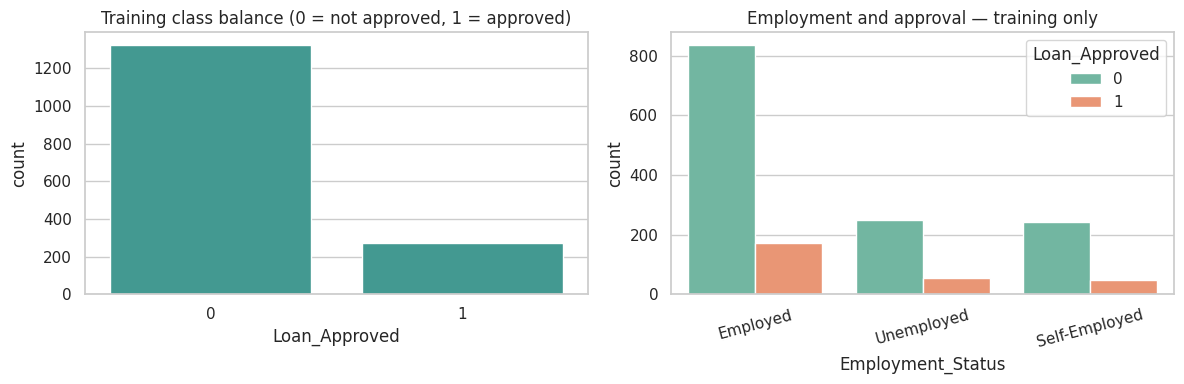

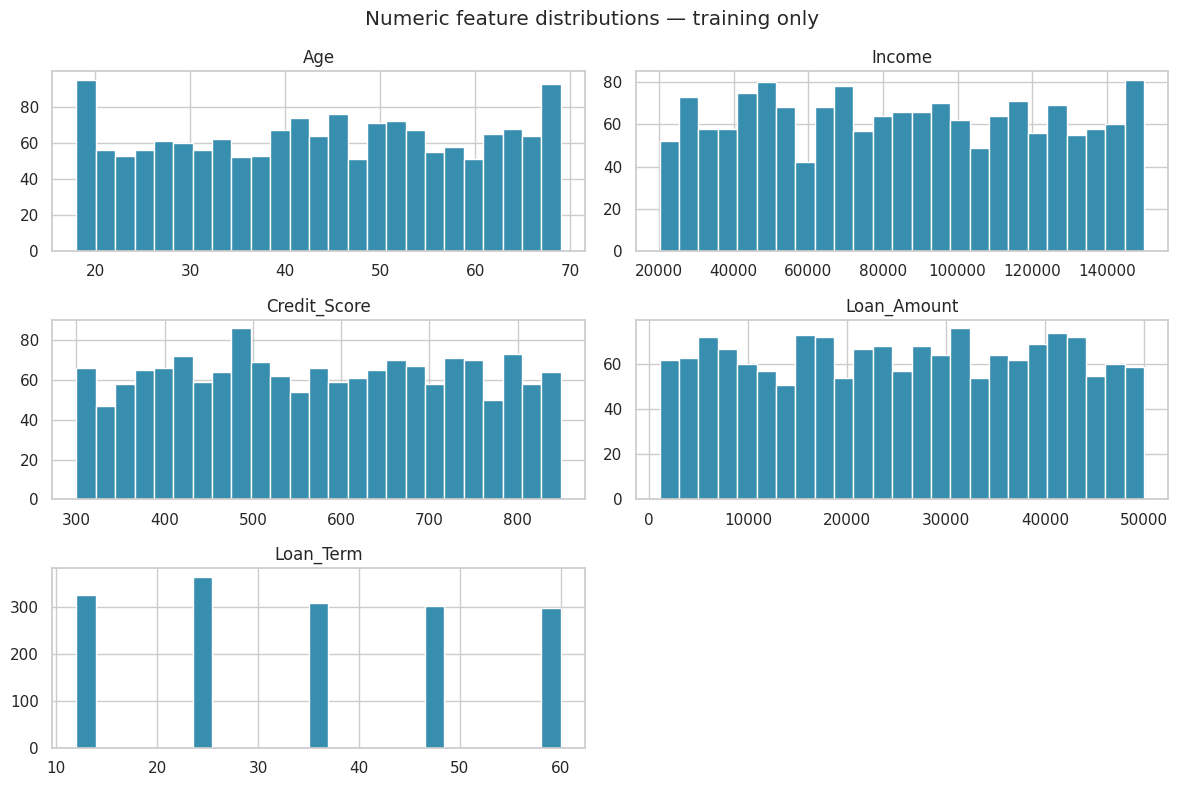

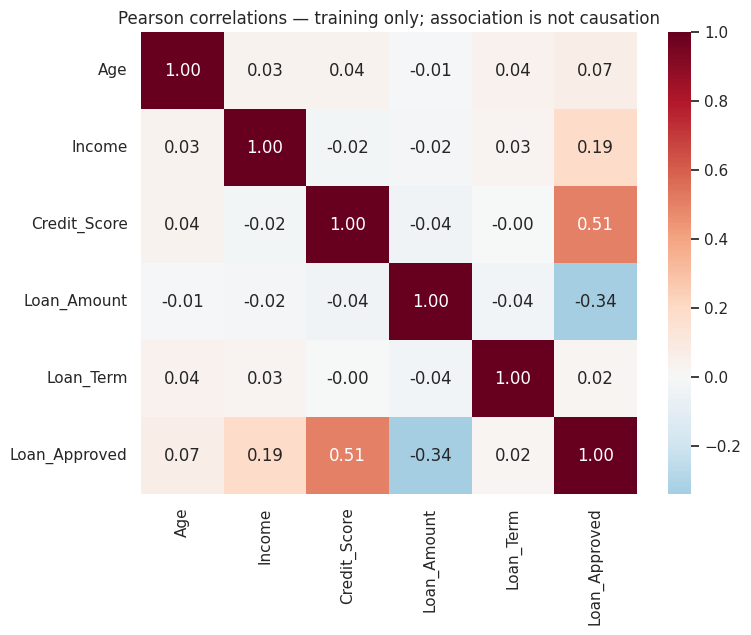

,feature,lower_fence,upper_fence,flagged_count,action
0,Age,-6.50,93.50,0,retain valid values
1,Income,-46452.25,215501.75,0,retain valid values
2,Credit_Score,33.50,1119.50,0,retain valid values
3,Loan_Amount,-23207.25,74620.75,0,retain valid values
4,Loan_Term,-12.00,84.00,0,retain valid values


Constant training columns: []
No hand-built income ratios: income periodicity and loan-term units are undocumented.


In [ ]:
eda = X_train.assign(Loan_Approved=y_train)
display(eda.describe(include='all').T)
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.countplot(data=eda, x=TARGET, ax=axes[0], color='#35a79c')
axes[0].set_title('Training class balance (0 = not approved, 1 = approved)')
sns.countplot(data=eda, x='Employment_Status', hue=TARGET, ax=axes[1])
axes[1].set_title('Employment and approval — training only')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
save_show('class_balance.png')
eda[NUMERIC].hist(bins=25, figsize=(12,8), color='#378eaf', edgecolor='white')
plt.suptitle('Numeric feature distributions — training only')
plt.tight_layout()
save_show('numeric_distributions.png')
plt.figure(figsize=(8,6))
sns.heatmap(eda[NUMERIC + [TARGET]].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Pearson correlations — training only; association is not causation')
save_show('correlations.png')

outlier_rows = []
for col in NUMERIC:
    q1, q3 = X_train[col].quantile([.25,.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = int(((X_train[col] < lower) | (X_train[col] > upper)).sum())
    outlier_rows.append({'feature':col,'lower_fence':lower,'upper_fence':upper,
                         'flagged_count':count,'action':'retain valid values'})
outlier_audit = pd.DataFrame(outlier_rows)
display(outlier_audit)
outlier_audit.to_csv(OUT / 'outlier_audit_training_only.csv', index=False)
print('Constant training columns:', X_train.columns[X_train.nunique(dropna=False) <= 1].tolist())
print('No hand-built income ratios: income periodicity and loan-term units are undocumented.')


## 7. Preprocessing inside each cross-validation fold


In [ ]:
def make_preprocessor():
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True)),
        ('scaler', StandardScaler())])
    category_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent', keep_empty_features=True)),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer([('numeric',numeric_pipe,NUMERIC),
                              ('categorical',category_pipe,CATEGORICAL)], remainder='drop')

def make_pipeline(model):
    return Pipeline([('preprocessor',make_preprocessor()),('model',model)])

# Diagnostic copy fitted on training only. Each CV pipeline fits its own fresh copy.
diagnostic_preprocessor = make_preprocessor()
train_transformed = diagnostic_preprocessor.fit_transform(X_train)
assert np.isfinite(train_transformed).all(), 'Preprocessing left NaN/inf values.'
print('Training matrix after preprocessing:', train_transformed.shape)
print('Remaining NaN values:', int(np.isnan(train_transformed).sum()))
print('Encoded columns:', diagnostic_preprocessor.get_feature_names_out().tolist())
display(pd.DataFrame(train_transformed, columns=diagnostic_preprocessor.get_feature_names_out()).head())


Training matrix after preprocessing: (1600, 8)
Remaining NaN values: 0
Encoded columns: ['numeric__Age', 'numeric__Income', 'numeric__Credit_Score', 'numeric__Loan_Amount', 'numeric__Loan_Term', 'categorical__Employment_Status_Employed', 'categorical__Employment_Status_Self-Employed', 'categorical__Employment_Status_Unemployed']


,numeric__Age,numeric__Income,numeric__Credit_Score,numeric__Loan_Amount,numeric__Loan_Term,categorical__Employment_Status_Employed,categorical__Employment_Status_Self-Employed,categorical__Employment_Status_Unemployed
0,0.743035,0.393391,-0.117322,0.164911,-0.659256,1.0,0.0,0.0
1,0.877286,-0.701842,0.590194,0.385159,-1.371483,1.0,0.0,0.0
2,0.608785,1.157495,0.864277,1.121476,-0.659256,1.0,0.0,0.0
3,-1.673476,-0.916207,-0.314916,0.233089,-0.659256,1.0,0.0,0.0
4,0.273158,0.742242,-0.799341,-1.521218,0.052972,1.0,0.0,0.0


## 8. Compare eight classifiers against a majority baseline



Dummy (majority)               CV accuracy=0.8287, F1=0.0000 (5.8s)
Logistic Regression            CV accuracy=0.9244, F1=0.7710 (0.9s)
Decision Tree                  CV accuracy=0.9975, F1=0.9926 (0.8s)
Random Forest                  CV accuracy=0.9975, F1=0.9926 (8.0s)
Extra Trees                    CV accuracy=0.9650, F1=0.8883 (5.7s)
Gradient Boosting              CV accuracy=0.9988, F1=0.9963 (2.5s)
Histogram Gradient Boosting    CV accuracy=0.9956, F1=0.9871 (4.9s)
SVM (RBF)                      CV accuracy=0.9606, F1=0.8793 (0.8s)
KNN                            CV accuracy=0.9437, F1=0.8205 (0.5s)


,model,train_accuracy,cv_accuracy_std,cv_accuracy,cv_balanced_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,cv_average_precision
0,Gradient Boosting,1.0000,0.0017,0.9988,0.9964,1.0000,0.9927,0.9963,0.9977,0.9953
1,Random Forest,1.0000,0.0026,0.9975,0.9927,1.0000,0.9854,0.9926,1.0000,0.9998
2,Decision Tree,1.0000,0.0041,0.9975,0.9927,1.0000,0.9855,0.9926,0.9927,0.9880
3,Histogram Gradient Boosting,1.0000,0.0042,0.9956,0.9902,0.9929,0.9818,0.9871,0.9978,0.9879
4,Extra Trees,1.0000,0.0087,0.9650,0.9080,0.9717,0.8213,0.8883,0.9945,0.9766
5,SVM (RBF),0.9725,0.0084,0.9606,0.9126,0.9279,0.8396,0.8793,0.9905,0.9611
6,KNN,0.9592,0.0063,0.9438,0.8691,0.9021,0.7556,0.8205,0.9785,0.9044
7,Logistic Regression,0.9283,0.0209,0.9244,0.8517,0.8080,0.7411,0.7710,0.9670,0.8738
8,Dummy (majority),0.8288,0.0014,0.8288,0.5000,0.0000,0.0000,0.0000,0.5000,0.1712


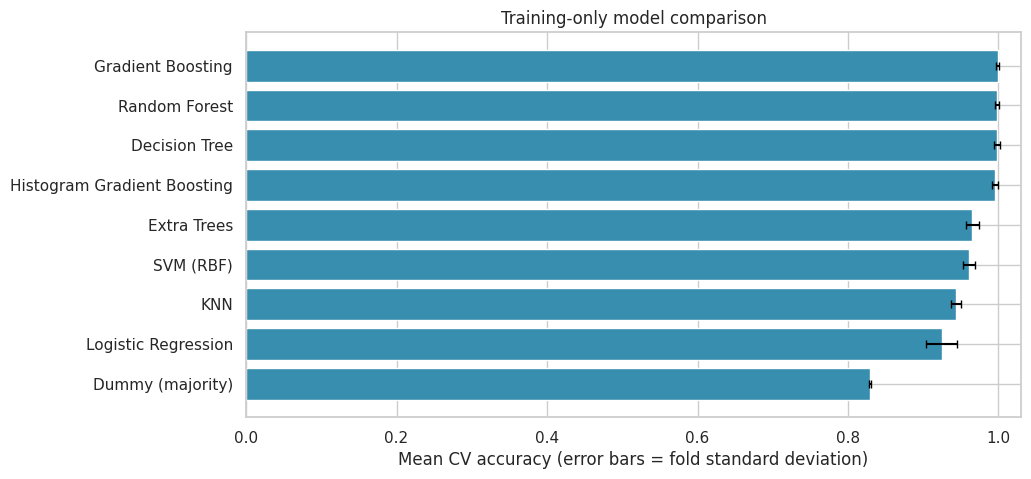

In [ ]:
models = {
    'Dummy (majority)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=250, n_jobs=1, random_state=SEED),
    'Extra Trees': ExtraTreesClassifier(n_estimators=250, n_jobs=1, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'Histogram Gradient Boosting': HistGradientBoostingClassifier(early_stopping=False, random_state=SEED),
    'SVM (RBF)': SVC(probability=True, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=11)
}
scoring = {'accuracy':'accuracy','balanced_accuracy':'balanced_accuracy',
           'precision':'precision','recall':'recall','f1':'f1',
           'roc_auc':'roc_auc','average_precision':'average_precision'}
# Explicit zero_division avoids undefined precision warnings for the majority baseline.
from sklearn.metrics import make_scorer
scoring['precision'] = make_scorer(precision_score, zero_division=0)
scoring['recall'] = make_scorer(recall_score, zero_division=0)
scoring['f1'] = make_scorer(f1_score, zero_division=0)
pipelines = {name:make_pipeline(model) for name,model in models.items()}
comparison_rows = []
for name, pipe in pipelines.items():
    start = time.time()
    result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                            n_jobs=N_JOBS, return_train_score=True, error_score='raise')
    row = {'model':name, 'train_accuracy':result['train_accuracy'].mean(),
           'cv_accuracy_std':result['test_accuracy'].std(ddof=1)}
    row.update({f'cv_{metric}':result[f'test_{metric}'].mean() for metric in scoring})
    comparison_rows.append(row)
    print(f'{name:30s} CV accuracy={row["cv_accuracy"]:.4f}, F1={row["cv_f1"]:.4f} ({time.time()-start:.1f}s)')
comparison = pd.DataFrame(comparison_rows).sort_values(
    ['cv_accuracy','cv_f1'], ascending=False).reset_index(drop=True)
display(comparison.round(4))
comparison.to_csv(OUT / 'model_comparison_cv.csv', index=False)
plt.figure(figsize=(10,5))
plt.barh(comparison.model[::-1], comparison.cv_accuracy[::-1],
         xerr=comparison.cv_accuracy_std[::-1], color='#378eaf', capsize=3)
plt.xlim(0,1.03)
plt.xlabel('Mean CV accuracy (error bars = fold standard deviation)')
plt.title('Training-only model comparison')
save_show('model_comparison_cv.png')


## 9. Tune the three strongest models



In [ ]:
search_spaces = {
 'Logistic Regression': {'model__C':[.01,.1,1,10,100], 'model__class_weight':[None,'balanced']},
 'Decision Tree': {'model__max_depth':[2,3,4,5,6,8,None],
                   'model__min_samples_leaf':[1,2,5,10,20],
                   'model__ccp_alpha':[0,.0005,.001,.005], 'model__class_weight':[None,'balanced']},
 'Random Forest': {'model__n_estimators':[200,400], 'model__max_depth':[4,6,10,None],
                   'model__min_samples_leaf':[1,2,5,10],
                   'model__max_features':['sqrt',.8,1.0], 'model__class_weight':[None,'balanced']},
 'Extra Trees': {'model__n_estimators':[200,400], 'model__max_depth':[5,10,None],
                 'model__min_samples_leaf':[1,2,5], 'model__max_features':['sqrt',.8,1.0],
                 'model__class_weight':[None,'balanced']},
 'Gradient Boosting': {'model__n_estimators':[100,200,300], 'model__learning_rate':[.03,.05,.1],
                       'model__max_depth':[1,2,3,4], 'model__min_samples_leaf':[1,5,15],
                       'model__subsample':[.8,1.0]},
 'Histogram Gradient Boosting': {'model__max_iter':[100,200,300],
     'model__learning_rate':[.03,.05,.1], 'model__max_leaf_nodes':[7,15,31],
     'model__min_samples_leaf':[10,20,30], 'model__l2_regularization':[0,1,5],
     'model__class_weight':[None,'balanced']},
 'SVM (RBF)': {'model__C':[.1,1,10,100], 'model__gamma':['scale',.01,.1,1],
               'model__class_weight':[None,'balanced']},
 'KNN': {'model__n_neighbors':[3,5,7,11,15,21,31],
         'model__weights':['uniform','distance'], 'model__p':[1,2]}
}
top_names = comparison.loc[comparison.model != 'Dummy (majority)','model'].head(3).tolist()
candidate_pipelines = {f'{name} | default':clone(pipe) for name,pipe in pipelines.items()}
candidate_rows = [{'candidate':r['model']+' | default', 'cv_accuracy':r['cv_accuracy'],
                   'cv_f1':r['cv_f1']} for r in comparison.to_dict('records')]
best_parameters = {}
for name in top_names:
    print('Tuning:', name, flush=True)
    space = search_spaces[name]
    combinations = int(np.prod([len(v) for v in space.values()]))
    search = RandomizedSearchCV(clone(pipelines[name]), space,
        n_iter=min(SEARCH_ITERATIONS,combinations), scoring=scoring, refit=PRIMARY_METRIC,
        cv=cv, n_jobs=N_JOBS, random_state=SEED, error_score='raise', return_train_score=True)
    search.fit(X_train,y_train)
    key = f'{name} | tuned'
    i = search.best_index_
    candidate_pipelines[key] = search.best_estimator_
    candidate_rows.append({'candidate':key,'cv_accuracy':search.cv_results_['mean_test_accuracy'][i],
                           'cv_f1':search.cv_results_['mean_test_f1'][i]})
    best_parameters[name] = search.best_params_
    print('Best parameters:',search.best_params_)
    print(f'Best CV accuracy: {search.best_score_:.4f}')
    pd.DataFrame(search.cv_results_).to_csv(OUT / (name.lower().replace(' ','_')+'_search.csv'),index=False)

candidate_table = pd.DataFrame(candidate_rows).sort_values(
    ['cv_accuracy','cv_f1'], ascending=False, kind='stable').reset_index(drop=True)
display(candidate_table.round(4))
candidate_table.to_csv(OUT / 'candidate_selection_cv.csv',index=False)
selected_name = candidate_table.iloc[0]['candidate']
selected_template = clone(candidate_pipelines[selected_name])
print('Selected before viewing test performance:', selected_name)


Tuning: Gradient Boosting
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_leaf': 15, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best CV accuracy: 0.9988
Tuning: Random Forest
Best parameters: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 6, 'model__class_weight': 'balanced'}
Best CV accuracy: 0.9988
Tuning: Decision Tree
Best parameters: {'model__min_samples_leaf': 20, 'model__max_depth': 4, 'model__class_weight': 'balanced', 'model__ccp_alpha': 0.005}
Best CV accuracy: 0.9988


,candidate,cv_accuracy,cv_f1
0,Gradient Boosting | default,0.9988,0.9963
1,Gradient Boosting | tuned,0.9988,0.9963
2,Random Forest | tuned,0.9988,0.9963
3,Decision Tree | tuned,0.9988,0.9963
4,Random Forest | default,0.9975,0.9926
5,Decision Tree | default,0.9975,0.9926
6,Histogram Gradient Boosting | default,0.9956,0.9871
7,Extra Trees | default,0.9650,0.8883
8,SVM (RBF) | default,0.9606,0.8793
9,KNN | default,0.9438,0.8205


Selected before viewing test performance: Gradient Boosting | default


## 10. Training-only threshold selection



,threshold,accuracy,balanced_accuracy,precision,recall,f1,distance_from_0_5
40,0.50,0.99875,0.99635,1.0,0.992701,0.996337,0.00
39,0.49,0.99875,0.99635,1.0,0.992701,0.996337,0.01
41,0.51,0.99875,0.99635,1.0,0.992701,0.996337,0.01
38,0.48,0.99875,0.99635,1.0,0.992701,0.996337,0.02
42,0.52,0.99875,0.99635,1.0,0.992701,0.996337,0.02
37,0.47,0.99875,0.99635,1.0,0.992701,0.996337,0.03
43,0.53,0.99875,0.99635,1.0,0.992701,0.996337,0.03
36,0.46,0.99875,0.99635,1.0,0.992701,0.996337,0.04
44,0.54,0.99875,0.99635,1.0,0.992701,0.996337,0.04
35,0.45,0.99875,0.99635,1.0,0.992701,0.996337,0.05


Frozen decision threshold: 0.50


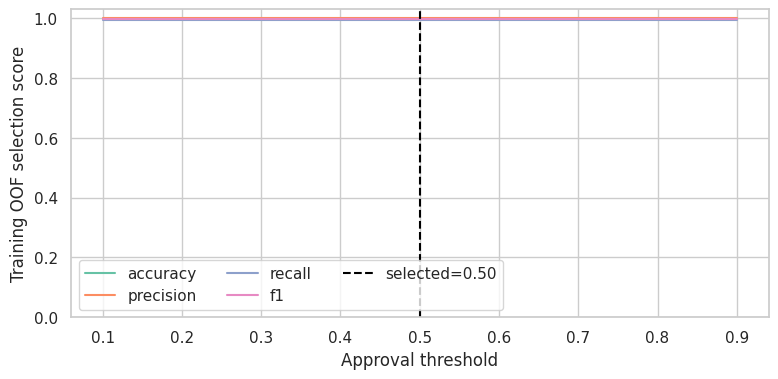

Model and threshold frozen. The next cell is the one-time test evaluation.


In [ ]:
oof_prob = cross_val_predict(selected_template, X_train, y_train, cv=cv,
                            method='predict_proba', n_jobs=N_JOBS)[:,1]
threshold_rows = []
for threshold in np.linspace(.10,.90,81):
    pred = (oof_prob >= threshold).astype(int)
    threshold_rows.append({'threshold':float(threshold),
        'accuracy':accuracy_score(y_train,pred), 'balanced_accuracy':balanced_accuracy_score(y_train,pred),
        'precision':precision_score(y_train,pred,zero_division=0),
        'recall':recall_score(y_train,pred,zero_division=0), 'f1':f1_score(y_train,pred,zero_division=0),
        'distance_from_0_5':abs(float(threshold)-.5)})
threshold_table = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_table.sort_values(
    ['accuracy','distance_from_0_5','threshold'], ascending=[False,True,True]).iloc[0]
THRESHOLD = float(best_threshold_row['threshold'])
display(threshold_table.sort_values(['accuracy','distance_from_0_5'],ascending=[False,True]).head(10))
threshold_table.to_csv(OUT / 'threshold_search_training_oof.csv',index=False)
print(f'Frozen decision threshold: {THRESHOLD:.2f}')
fig,ax = plt.subplots(figsize=(9,4))
for metric in ['accuracy','precision','recall','f1']:
    ax.plot(threshold_table.threshold,threshold_table[metric],label=metric)
ax.axvline(THRESHOLD,color='black',ls='--',label=f'selected={THRESHOLD:.2f}')
ax.set(xlabel='Approval threshold',ylabel='Training OOF selection score',ylim=(0,1.03))
ax.legend(ncol=3)
save_show('threshold_selection.png')

evaluation_model = clone(selected_template).fit(X_train,y_train)
assert evaluation_model.classes_.tolist() == [0,1]
print('Model and threshold frozen. The next cell is the one-time test evaluation.')


## 11. Final held-out evaluation and confusion matrices



,accuracy,balanced_accuracy,precision_approved,recall_approved,f1_approved,roc_auc,average_precision
Majority baseline,0.83,0.5,0.0,0.0,0.0,0.5,0.17
Selected model,1.00,1.0,1.0,1.0,1.0,1.0,1.00


Selected model: Gradient Boosting | default
Training accuracy (resubstitution): 100.00%
HELD-OUT TEST ACCURACY: 100.00%
Accuracy gain over test baseline: 17.00 percentage points
95% Wilson interval for test accuracy: 99.05% to 100.00% (n=400)
                  precision    recall  f1-score   support

Not approved (0)     1.0000    1.0000    1.0000       332
    Approved (1)     1.0000    1.0000    1.0000        68

        accuracy                         1.0000       400
       macro avg     1.0000    1.0000    1.0000       400
    weighted avg     1.0000    1.0000    1.0000       400

TN=332, FP=0, FN=0, TP=68


,Predicted 0: not approved,Predicted 1: approved
Actual 0: not approved,332,0
Actual 1: approved,0,68


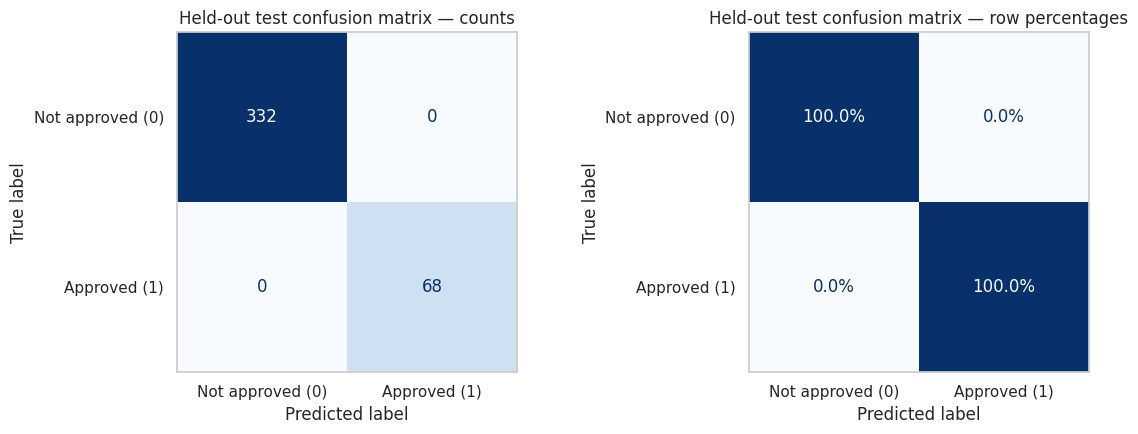

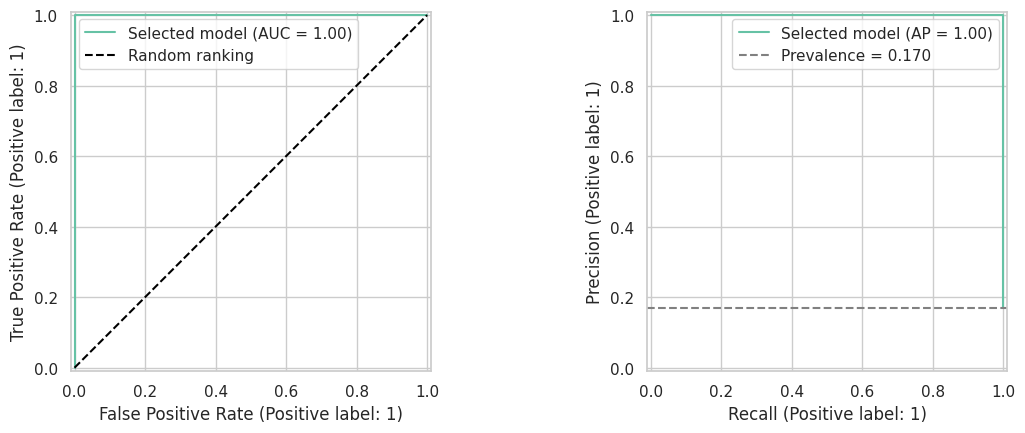

In [ ]:
test_probability = evaluation_model.predict_proba(X_test)[:,1]
test_prediction = (test_probability >= THRESHOLD).astype(int)
baseline_model = clone(pipelines['Dummy (majority)']).fit(X_train,y_train)
baseline_prediction = baseline_model.predict(X_test)
def metric_dict(actual,pred,prob):
    return {'accuracy':float(accuracy_score(actual,pred)),
            'balanced_accuracy':float(balanced_accuracy_score(actual,pred)),
            'precision_approved':float(precision_score(actual,pred,zero_division=0)),
            'recall_approved':float(recall_score(actual,pred,zero_division=0)),
            'f1_approved':float(f1_score(actual,pred,zero_division=0)),
            'roc_auc':float(roc_auc_score(actual,prob)),
            'average_precision':float(average_precision_score(actual,prob))}
metrics = metric_dict(y_test,test_prediction,test_probability)
baseline_metrics = metric_dict(y_test,baseline_prediction,baseline_model.predict_proba(X_test)[:,1])
metric_table = pd.DataFrame([baseline_metrics,metrics],index=['Majority baseline','Selected model'])
display(metric_table.round(4))
metric_table.to_csv(OUT / 'heldout_metrics.csv')
train_prediction = (evaluation_model.predict_proba(X_train)[:,1] >= THRESHOLD).astype(int)
print('Selected model:',selected_name)
print(f'Training accuracy (resubstitution): {accuracy_score(y_train,train_prediction):.2%}')
print(f'HELD-OUT TEST ACCURACY: {metrics["accuracy"]:.2%}')
print(f'Accuracy gain over test baseline: {(metrics["accuracy"]-baseline_metrics["accuracy"])*100:.2f} percentage points')
n = len(y_test)
p = metrics['accuracy']
z = 1.959963984540054
den = 1 + z*z/n
center = (p + z*z/(2*n))/den
half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
accuracy_ci = [float(center-half),float(center+half)]
print(f'95% Wilson interval for test accuracy: {accuracy_ci[0]:.2%} to {accuracy_ci[1]:.2%} (n={n})')
print(classification_report(y_test,test_prediction,labels=[0,1],
      target_names=['Not approved (0)','Approved (1)'],digits=4,zero_division=0))
report = pd.DataFrame(classification_report(y_test,test_prediction,labels=[0,1],
    target_names=['Not approved (0)','Approved (1)'],output_dict=True,zero_division=0)).T
report.to_csv(OUT / 'classification_report.csv')
cm = confusion_matrix(y_test,test_prediction,labels=[0,1])
tn,fp,fn,tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
cm_table = pd.DataFrame(cm,index=['Actual 0: not approved','Actual 1: approved'],
                       columns=['Predicted 0: not approved','Predicted 1: approved'])
display(cm_table)
cm_table.to_csv(OUT / 'confusion_matrix_counts.csv')
fig,axes = plt.subplots(1,2,figsize=(12,4.5))
labels = ['Not approved (0)','Approved (1)']
ConfusionMatrixDisplay.from_predictions(y_test,test_prediction,labels=[0,1],display_labels=labels,
    cmap='Blues',colorbar=False,ax=axes[0])
axes[0].set_title('Held-out test confusion matrix — counts')
ConfusionMatrixDisplay.from_predictions(y_test,test_prediction,labels=[0,1],display_labels=labels,
    normalize='true',values_format='.1%',cmap='Blues',colorbar=False,ax=axes[1])
axes[1].set_title('Held-out test confusion matrix — row percentages')
axes[0].grid(False)
axes[1].grid(False)
plt.tight_layout()
save_show('confusion_matrix.png')

fig,axes = plt.subplots(1,2,figsize=(12,4.5))
RocCurveDisplay.from_predictions(y_test,test_probability,ax=axes[0],name='Selected model')
axes[0].plot([0,1],[0,1],'k--',label='Random ranking')
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test,test_probability,ax=axes[1],name='Selected model')
axes[1].axhline(y_test.mean(),ls='--',color='gray',label=f'Prevalence = {y_test.mean():.3f}')
axes[1].legend()
plt.tight_layout()
save_show('roc_and_precision_recall.png')
assert int(cm.sum()) == len(X_test)
assert np.isfinite(test_probability).all()
assert np.logical_and(test_probability >= 0,test_probability <= 1).all()


## 12. Feature importance and error inspection



,feature,mean_auc_decrease,std_auc_decrease
2,Credit_Score,0.3708,0.0295
3,Loan_Amount,0.2405,0.0174
1,Income,0.1633,0.0251
0,Age,0.0000,0.0000
4,Loan_Term,0.0000,0.0000
5,Employment_Status,0.0000,0.0000


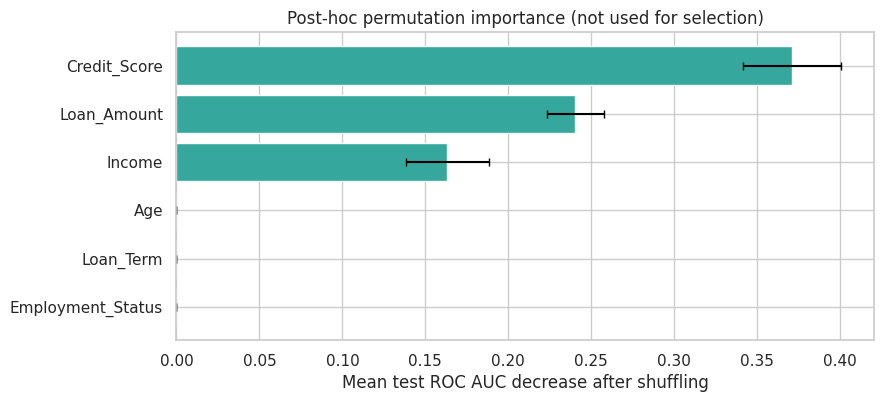

Misclassified test rows: 0


,Source_Row,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Actual,Predicted,Approval_Score,Correct


Near-perfect results warrant checking whether labels were generated by a simple rule or the data are synthetic.
No feature, hyperparameter or threshold changes are made from this error review.


In [ ]:
importance_result = permutation_importance(evaluation_model,X_test,y_test,
    scoring='roc_auc',n_repeats=15,random_state=SEED,n_jobs=N_JOBS)
importance = pd.DataFrame({'feature':FEATURES,'mean_auc_decrease':importance_result.importances_mean,
                          'std_auc_decrease':importance_result.importances_std}).sort_values(
                              'mean_auc_decrease',ascending=False)
display(importance.round(4))
importance.to_csv(OUT / 'permutation_importance.csv',index=False)
plt.figure(figsize=(9,4))
plt.barh(importance.feature[::-1],importance.mean_auc_decrease[::-1],
         xerr=importance.std_auc_decrease[::-1],color='#35a79c',capsize=3)
plt.xlabel('Mean test ROC AUC decrease after shuffling')
plt.title('Post-hoc permutation importance (not used for selection)')
save_show('feature_importance.png')
test_results = X_test.copy()
test_results.insert(0,'Source_Row',df.loc[X_test.index,'Source_Row'])
test_results['Actual'] = y_test
test_results['Predicted'] = test_prediction
test_results['Approval_Score'] = test_probability
test_results['Correct'] = test_results.Actual.eq(test_results.Predicted)
test_results.to_csv(OUT / 'test_predictions.csv',index=False)
errors = test_results.loc[~test_results.Correct].copy()
errors.to_csv(OUT / 'misclassified_test_rows.csv',index=False)
print('Misclassified test rows:',len(errors))
display(errors.head(15))
if metrics['accuracy'] >= .98:
    print('Near-perfect results warrant checking whether labels were generated by a simple rule or the data are synthetic.')
print('No feature, hyperparameter or threshold changes are made from this error review.')


## 13. Save the evaluation model, preprocessing, metadata and reusable prediction code



In [ ]:
import inspect
# Store the exact source of the notebook's cleaning function without relying on inspect in Colab.
CLEAN_FEATURES_SOURCE = 'def clean_features(frame):\n    """Fixed, row-wise cleaning only. Learned imputation happens inside the model pipeline."""\n    result = frame.copy()\n    result.columns = [str(c).strip() for c in result.columns]\n    if result.columns.duplicated().any():\n        raise ValueError(\'Column names become duplicated after trimming.\')\n    absent = set(FEATURES) - set(result.columns)\n    if absent:\n        raise ValueError(f\'Missing required features: {sorted(absent)}\')\n    result = result[FEATURES].copy()\n    for col in NUMERIC:\n        result[col] = pd.to_numeric(result[col], errors=\'coerce\').replace([np.inf, -np.inf], np.nan)\n        invalid = result[col].lt(0) if col != \'Loan_Term\' else result[col].le(0)\n        result.loc[invalid, col] = np.nan\n    tokens = {\'\', \'na\', \'n/a\', \'null\', \'none\', \'nan\', \'?\'}\n    mapping = {\'employed\':\'Employed\', \'self-employed\':\'Self-Employed\',\n               \'self employed\':\'Self-Employed\', \'self_employed\':\'Self-Employed\',\n               \'unemployed\':\'Unemployed\'}\n    def normalize(value):\n        if pd.isna(value):\n            return np.nan\n        value = str(value).strip()\n        return np.nan if value.lower() in tokens else mapping.get(value.lower(), value)\n    result[\'Employment_Status\'] = result[\'Employment_Status\'].map(normalize)\n    return result\n'
inference_source = "import numpy as np\nimport pandas as pd\nimport joblib\n" +     f"FEATURES = {FEATURES!r}\nNUMERIC = {NUMERIC!r}\n" + CLEAN_FEATURES_SOURCE + "\n" +     "def predict_loans(frame, model_path='evaluation_model.joblib'):\n" +     "    bundle = joblib.load(model_path)\n" +     "    clean = clean_features(frame)\n" +     "    score = bundle['pipeline'].predict_proba(clean)[:, 1]\n" +     "    return pd.DataFrame({'Approval_Score': score, 'Loan_Approved': (score >= bundle['threshold']).astype(int)}, index=frame.index)\n"
(OUT / 'loan_inference.py').write_text(inference_source)
bundle = {'pipeline':evaluation_model,'threshold':THRESHOLD,'features':FEATURES,
          'target_mapping':{0:'Not approved',1:'Approved'},'selected_model':selected_name,
          'package_versions':VERSIONS,'training_scope':'training split only'}
joblib.dump(bundle,OUT / 'evaluation_model.joblib')
metadata = {'dataset':DATA_PATH.name,'sha256':source_sha256,'rows_raw':len(raw),
    'rows_labeled_after_cleaning':len(df),'train_rows':len(X_train),'test_rows':len(X_test),
    'seed':SEED,'cv_folds':N_SPLITS,'primary_metric':PRIMARY_METRIC,
    'selected_model':selected_name,'threshold':THRESHOLD,'test_metrics':metrics,
    'accuracy_95pct_wilson_interval':accuracy_ci,'confusion_matrix':cm.tolist(),
    'best_parameters':best_parameters,'package_versions':VERSIONS,
    'validation_note':'Training-only model/threshold selection; one reserved stratified test split.',
    'limitations':['Dataset origin and score/financial units are undocumented.',
                  'Independent-row assumption; no applicant IDs or dates available.',
                  'Predicts historical approval labels, not default or repayment.',
                  'Scores are not independently calibrated probabilities.']}
(OUT / 'run_metadata.json').write_text(json.dumps(metadata,indent=2))
(OUT / 'requirements.txt').write_text('\n'.join(f'{p}=={v}' for p,v in VERSIONS.items())+'\n')
# Verify the saved model and raw-input helper agree with the evaluated predictions.
import importlib.util
spec = importlib.util.spec_from_file_location('loan_inference',OUT / 'loan_inference.py')
inference = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inference)
reloaded = inference.predict_loans(X_test,OUT / 'evaluation_model.joblib')
assert np.array_equal(reloaded.Loan_Approved.to_numpy(),test_prediction)
assert np.allclose(reloaded.Approval_Score.to_numpy(),test_probability)
# Exercise missing values and unseen categories on training examples, not new test decisions.
smoke = X_train.head(2).copy()
smoke.loc[smoke.index[0],NUMERIC] = np.nan
smoke.loc[smoke.index[0],'Employment_Status'] = np.nan
smoke.loc[smoke.index[1],'Employment_Status'] = 'Previously unseen category'
assert inference.predict_loans(smoke,OUT / 'evaluation_model.joblib').notna().all().all()
print('Saved-model round trip, missing-value handling and unseen-category checks passed.')


Saved-model round trip, missing-value handling and unseen-category checks passed.


## 14. Predict a new example; optionally refit on all labeled rows



In [ ]:
example = pd.DataFrame([{'Age':35,'Income':80000,'Credit_Score':720,
                         'Loan_Amount':15000,'Loan_Term':36,'Employment_Status':'Employed'}])
display(pd.concat([example,inference.predict_loans(example,OUT / 'evaluation_model.joblib')],axis=1))
if len(unlabeled_rows):
    unlabelled_predictions = inference.predict_loans(unlabeled_rows,OUT / 'evaluation_model.joblib')
    pd.concat([unlabeled_rows,unlabelled_predictions],axis=1).to_csv(OUT / 'unlabeled_predictions.csv',index=False)

REFIT_ON_ALL_DATA = False
if REFIT_ON_ALL_DATA:
    full_data_bundle = dict(bundle)
    full_data_bundle['pipeline'] = clone(selected_template).fit(X,y)
    full_data_bundle['training_scope'] = 'all labeled rows; no independent evaluation after refit'
    joblib.dump(full_data_bundle,OUT / 'full_data_model.joblib')
    print('Saved separate full_data_model.joblib. No new accuracy claim is made.')


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Approval_Score,Loan_Approved
0,35,80000,720,15000,36,Employed,0.999966,1


## 15. Download the complete results



In [ ]:
summary = f"""Loan approval prediction — executed run
Selected model: {selected_name}
Frozen approval threshold: {THRESHOLD:.2f}
Train / test rows: {len(X_train)} / {len(X_test)}
Held-out accuracy: {metrics['accuracy']:.4%}
Approved precision: {metrics['precision_approved']:.4%}
Approved recall: {metrics['recall_approved']:.4%}
Approved F1: {metrics['f1_approved']:.4f}
ROC AUC: {metrics['roc_auc']:.4f}
Average precision: {metrics['average_precision']:.4f}
Confusion matrix [[TN, FP], [FN, TP]]: {cm.tolist()}
Evaluation model was fitted on the training split only.
All model, preprocessing and threshold choices were made without test-set evaluation.
Model-selection CV scores are selection estimates, not independent validation.
Dataset provenance, external validity, and calibration are not established.
"""
print(summary)
(OUT / 'README_results.txt').write_text(summary)
zip_path = shutil.make_archive('loan_prediction_results','zip',OUT)
print('Results ZIP:',zip_path)
AUTO_DOWNLOAD_RESULTS = True
try:
    from google.colab import files
except ImportError:
    display(FileLink(zip_path))
else:
    if AUTO_DOWNLOAD_RESULTS:
        files.download(zip_path)
    else:
        print('Download loan_prediction_results.zip from the Colab Files panel.')


Loan approval prediction — executed run
Selected model: Gradient Boosting | default
Frozen approval threshold: 0.50
Train / test rows: 1600 / 400
Held-out accuracy: 100.0000%
Approved precision: 100.0000%
Approved recall: 100.0000%
Approved F1: 1.0000
ROC AUC: 1.0000
Average precision: 1.0000
Confusion matrix [[TN, FP], [FN, TP]]: [[332, 0], [0, 68]]
Evaluation model was fitted on the training split only.
All model, preprocessing and threshold choices were made without test-set evaluation.
Model-selection CV scores are selection estimates, not independent validation.
Dataset provenance, external validity, and calibration are not established.

Results ZIP: /content/loan_prediction_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>